In [3]:
import sys
from pathlib import Path
# Procura a raiz do projeto (pasta que contém `src`) subindo na arvore
def find_project_root(start: Path = Path.cwd()) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'src').is_dir():
            return p
    return start
proj_root = str(find_project_root())
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)
print('Project root added to sys.path:', proj_root)

from src.config import *


Project root added to sys.path: c:\Users\Pedro\Downloads\LIBS_NEW


In [5]:
list_dirs()

BASE_DIR:  C:\Users\Pedro\Downloads\LIBS_NEW 
DATA_DIR:  C:\Users\Pedro\Downloads\LIBS_NEW\dataset 
MODELS_DIR:  C:\Users\Pedro\Downloads\LIBS_NEW\models 
PLOTS_DIR: C:\Users\Pedro\Downloads\LIBS_NEW\plots


Dataset: laser266.dat
Amostras A usadas: 600
Amostras R usadas: 500


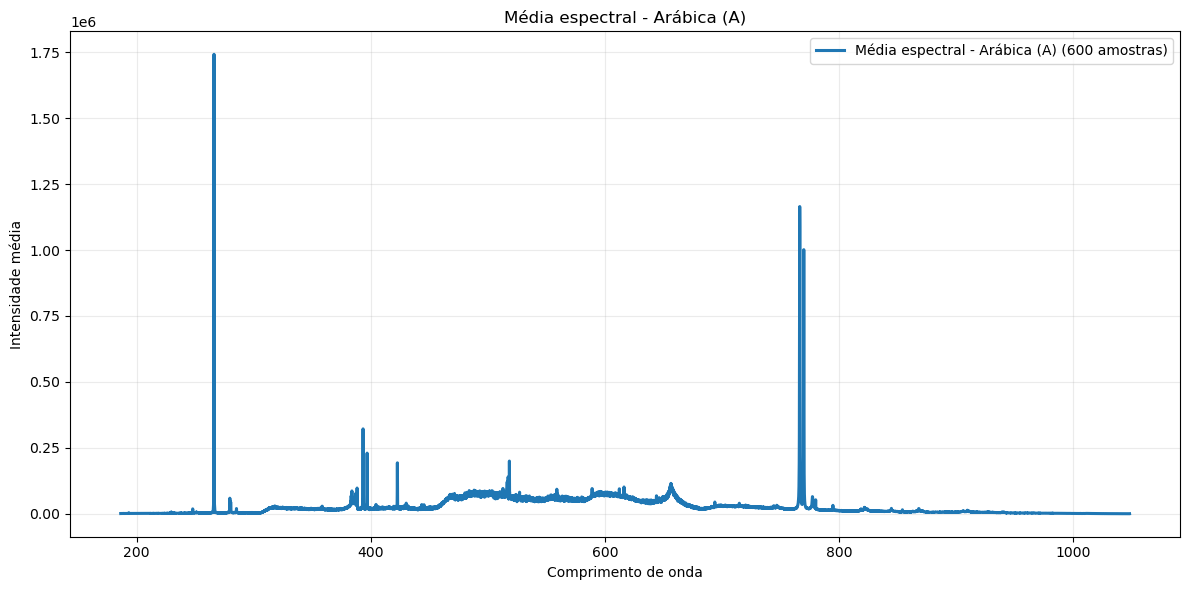

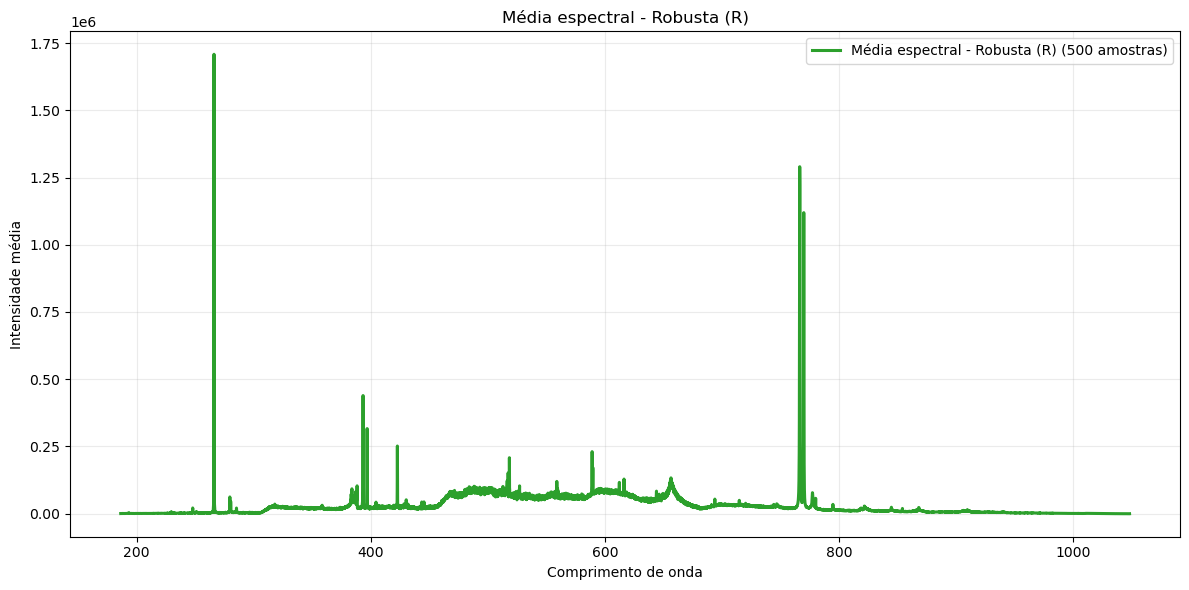

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ARABICA_EXTRA_LABELS = {
    'C_Pilao_sample',
    'C_Evolutto_sample',
    'C_Do_Ponto_sample',
    'C_America_sample',
    'C_Coamo_sample',
}


def normalizar_label(label):
    return str(label).strip()


def carregar_dataset_laser266():
    dataset_path = DATA_DIR / 'laser266.dat'

    if not dataset_path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {dataset_path}')

    df = pd.read_csv(dataset_path, sep=';', header=None, low_memory=False)

    wavelengths = pd.to_numeric(df.iloc[1:, 0], errors='coerce').to_numpy()
    labels = df.iloc[0, 1:].astype(str).to_numpy()
    spectra = df.iloc[1:, 1:].apply(pd.to_numeric, errors='coerce').to_numpy().T

    return wavelengths, labels, spectra, dataset_path


def selecionar_grupo(labels, spectra, grupo):
    grupo = grupo.strip().upper()
    selecionados = []
    selecionados_labels = []

    for label, spectrum in zip(labels, spectra):
        texto = normalizar_label(label)

        if grupo == 'A':
            if texto.startswith('A') or texto in ARABICA_EXTRA_LABELS:
                selecionados.append(spectrum)
                selecionados_labels.append(texto)
        elif grupo == 'R':
            if texto.startswith('R'):
                selecionados.append(spectrum)
                selecionados_labels.append(texto)
        else:
            raise ValueError('Grupo inválido. Use apenas A ou R.')

    if not selecionados:
        raise ValueError(f'Nenhuma amostra encontrada para o grupo {grupo}.')

    return np.vstack(selecionados).mean(axis=0), selecionados_labels


def plotar_media(wavelengths, media, labels, titulo, cor):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(wavelengths, media, color=cor, linewidth=2.2, label=f'{titulo} ({len(labels)} amostras)')
    ax.set_title(titulo)
    ax.set_xlabel('Comprimento de onda')
    ax.set_ylabel('Intensidade média')
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()


wavelengths, labels, spectra, dataset_path = carregar_dataset_laser266()

media_a, labels_a = selecionar_grupo(labels, spectra, 'A')
media_r, labels_r = selecionar_grupo(labels, spectra, 'R')

print(f'Dataset: {dataset_path.name}')
print(f'Amostras A usadas: {len(labels_a)}')
print(f'Amostras R usadas: {len(labels_r)}')

plotar_media(wavelengths, media_a, labels_a, 'Média espectral - Arábica (A)', 'tab:blue')
plotar_media(wavelengths, media_r, labels_r, 'Média espectral - Robusta (R)', 'tab:green')

Diferença calculada com 12288 pontos espectrais


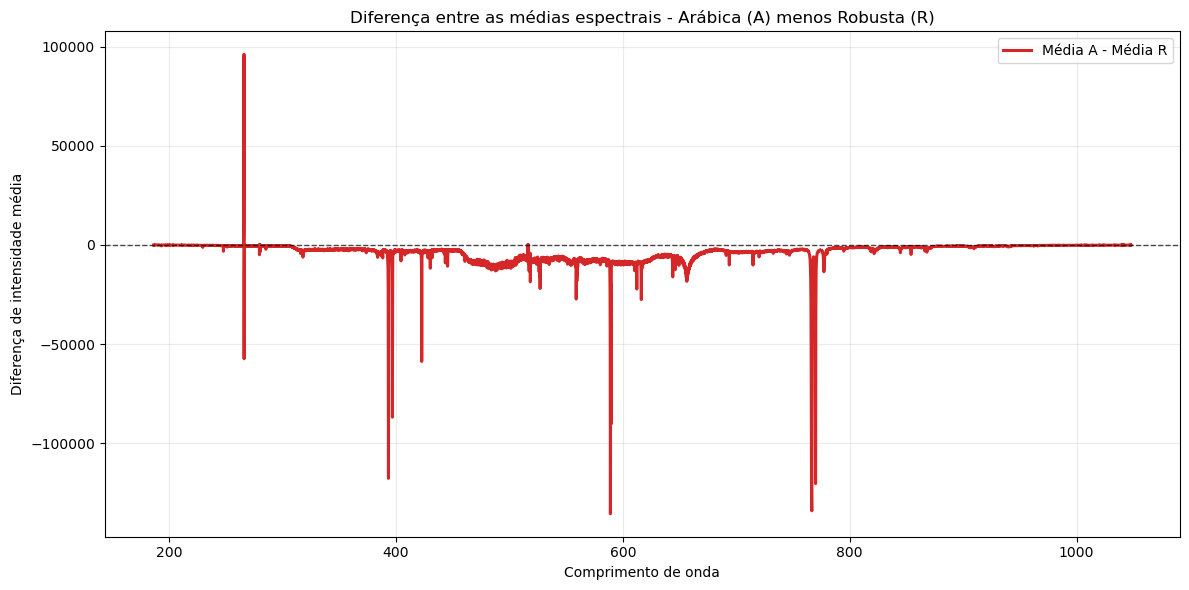

In [8]:
import matplotlib.pyplot as plt
import numpy as np


diferenca_media = media_a - media_r

print(f'Diferença calculada com {len(diferenca_media)} pontos espectrais')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavelengths, diferenca_media, color='tab:red', linewidth=2.2, label='Média A - Média R')
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.set_title('Diferença entre as médias espectrais - Arábica (A) menos Robusta (R)')
ax.set_xlabel('Comprimento de onda')
ax.set_ylabel('Diferença de intensidade média')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()